In [1]:
# !pip install opencv-python imgbeddings psycopg2-binary

In [2]:
import cv2
import matplotlib.pyplot as plt

In [3]:
# algorithm from github and loading it
alg = '/Users/gabrielaslomiany/PycharmProjects/Biometry/Face-Recognition/haarcascade_frontalface_default.xml'
haar_cascade = cv2.CascadeClassifier(alg)

file_name = 'modernfamily.jpg'
img = cv2.imread(file_name)
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# detecting faces from the picture
faces = haar_cascade.detectMultiScale(gray, scaleFactor=1.05, minNeighbors=5, minSize=(100, 100))

i=0
# for each face detected
for x, y, w, h in faces:
    cropped_image = gray[y : y + h, x : x + w]
    # do not forget about creating folder
    target_file_name = '/Users/gabrielaslomiany/PycharmProjects/Biometry/Face-Recognition/stored_faces/' + str(i) + '.jpg'
    cv2.imwrite(target_file_name, cropped_image)
    i = i + 1;

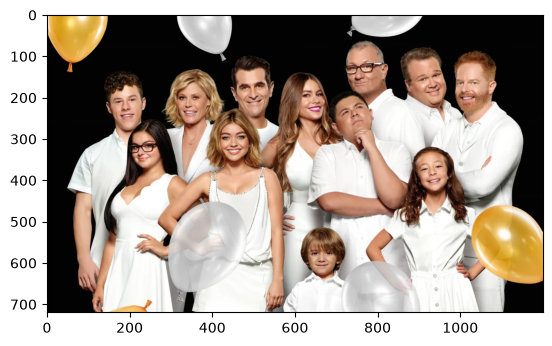

In [7]:
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.show()

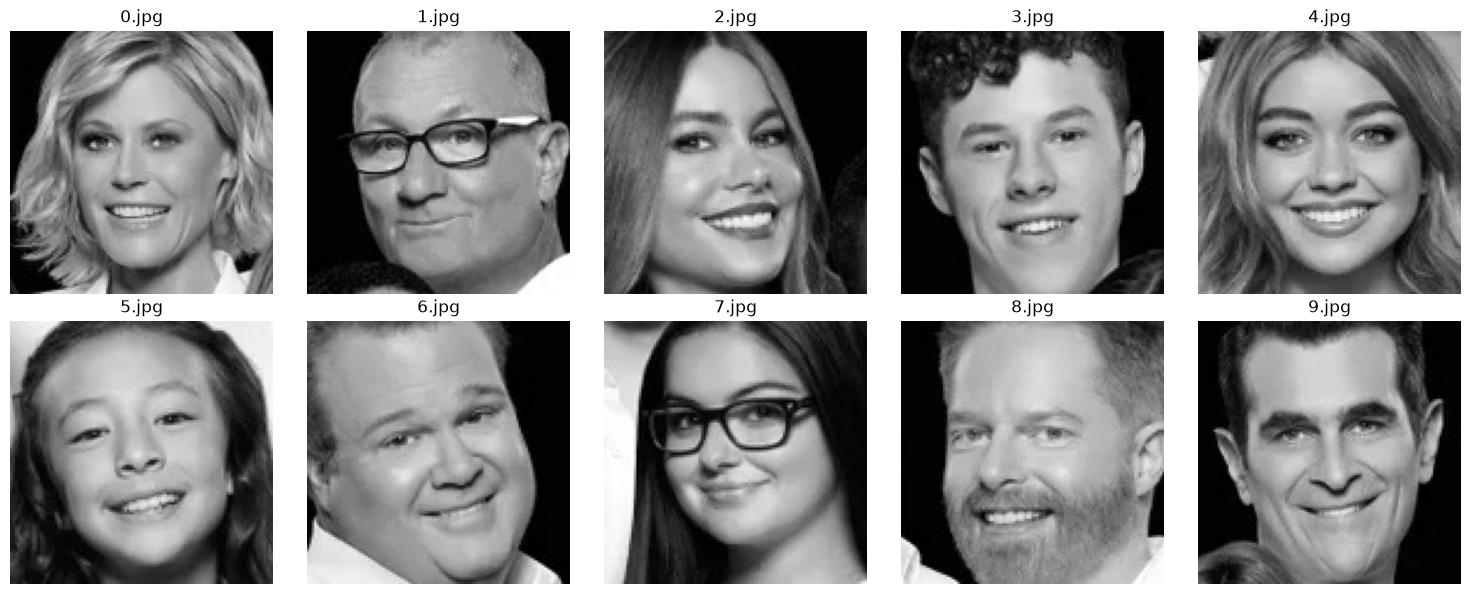

In [10]:
import glob
import os
import math

stored_faces_dir = '/Users/gabrielaslomiany/PycharmProjects/Biometry/Face-Recognition/stored_faces'
face_files = sorted(
    glob.glob(os.path.join(stored_faces_dir, '*.jpg')),
    key=lambda p: int(os.path.splitext(os.path.basename(p))[0])
)

n = len(face_files)
cols = 5
rows = math.ceil(n / cols)

fig, axes = plt.subplots(rows, cols, figsize=(3 * cols, 3 * rows))

for ax, face_file in zip(axes.flat, face_files):
    face_img = cv2.imread(face_file)
    ax.imshow(cv2.cvtColor(face_img, cv2.COLOR_BGR2RGB))
    ax.set_title(os.path.basename(face_file))
    ax.axis('off')

# hide any unused subplot slots
for ax in axes.flat[n:]:
    ax.axis('off')

plt.tight_layout()
plt.show()